<a href="https://colab.research.google.com/github/IrumShehryar/ML-NLP-Coursework/blob/main/nlp/topic_modeling/Project01_LDA_TopicModeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import style
style.use('dark_background')
import nltk
import textwrap   # Wraps the single paragraph in text, and returns a single string containing the wrapped paragraph

from nltk.corpus import stopwords

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

In [2]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

# Read the dataset

In [6]:
%cd /content/drive/MyDrive/NLP-course/Course Material/Topic Modeling

/content/drive/MyDrive/NLP-course/Course Material/Topic Modeling


In [7]:
df = pd.read_csv('bbc-text.csv')

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
df.shape

(2225, 2)

In [9]:
df.head()

,category,text
0,tech,tv future in the hands of viewers with home th...
1,business,worldcom boss left books alone former worldc...
2,sport,tigers wary of farrell gamble leicester say ...
3,sport,yeading face newcastle in fa cup premiership s...
4,entertainment,ocean s twelve raids box office ocean s twelve...


# Since Topic Modeling is unsupervised, therefore we just need features

In [10]:
features = df['text']

# Instantiate Count Vectorizer and fit to the features

In [11]:
vectorizer = CountVectorizer(stop_words = 'english') # since model itself based on wordcount, therefore we are not using TFIDF

In [12]:
X = vectorizer.fit_transform(features)

In [13]:
X # This is document by word Matrix

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 322146 stored elements and shape (2225, 29126)>

# Instantiate LDA

In [14]:
lda_model = LatentDirichletAllocation(n_components=5, random_state = 42) # default: n_components = 10
# Number of components means number of topics. Changing random state will change the results

In [15]:
lda_model.fit(X)

LatentDirichletAllocation(n_components=5, random_state=42)

## The following code is copied from the scikit learn documention. This function plots the bar plot of each topic. It will show the top 10 words for each topic. This function will give topic by words matrix

In [16]:
def plot_top_words(model, feature_names, n_top_words=10):
  fig, axes = plt.subplots(1, 5, figsize=(30, 15), sharex=True)
  axes = axes.flatten()
  for topic_idx, topic in enumerate(model.components_):
    top_features_ind = topic.argsort()[: -n_top_words - 1 : -1]
    top_features = [feature_names[i] for i in top_features_ind]
    weights = topic[top_features_ind]

    ax = axes[topic_idx]
    ax.barh(top_features, weights, height=0.7)
    ax.set_title(f"Topic {topic_idx +1}", fontdict={"fontsize": 30})
    ax.invert_yaxis()
    ax.tick_params(axis="both", which="major", labelsize=20)
    for i in "top right left".split():
        ax.spines[i].set_visible(False)
    fig.suptitle('LDA', fontsize=40)

  plt.subplots_adjust(top=0.90, bottom=0.05, wspace=0.90, hspace=0.3)
  plt.show()

# Get the total words OR Vocab of the dataset

In [17]:
feature_names = vectorizer.get_feature_names_out()

In [18]:
len(feature_names)

29126

# Apply the function

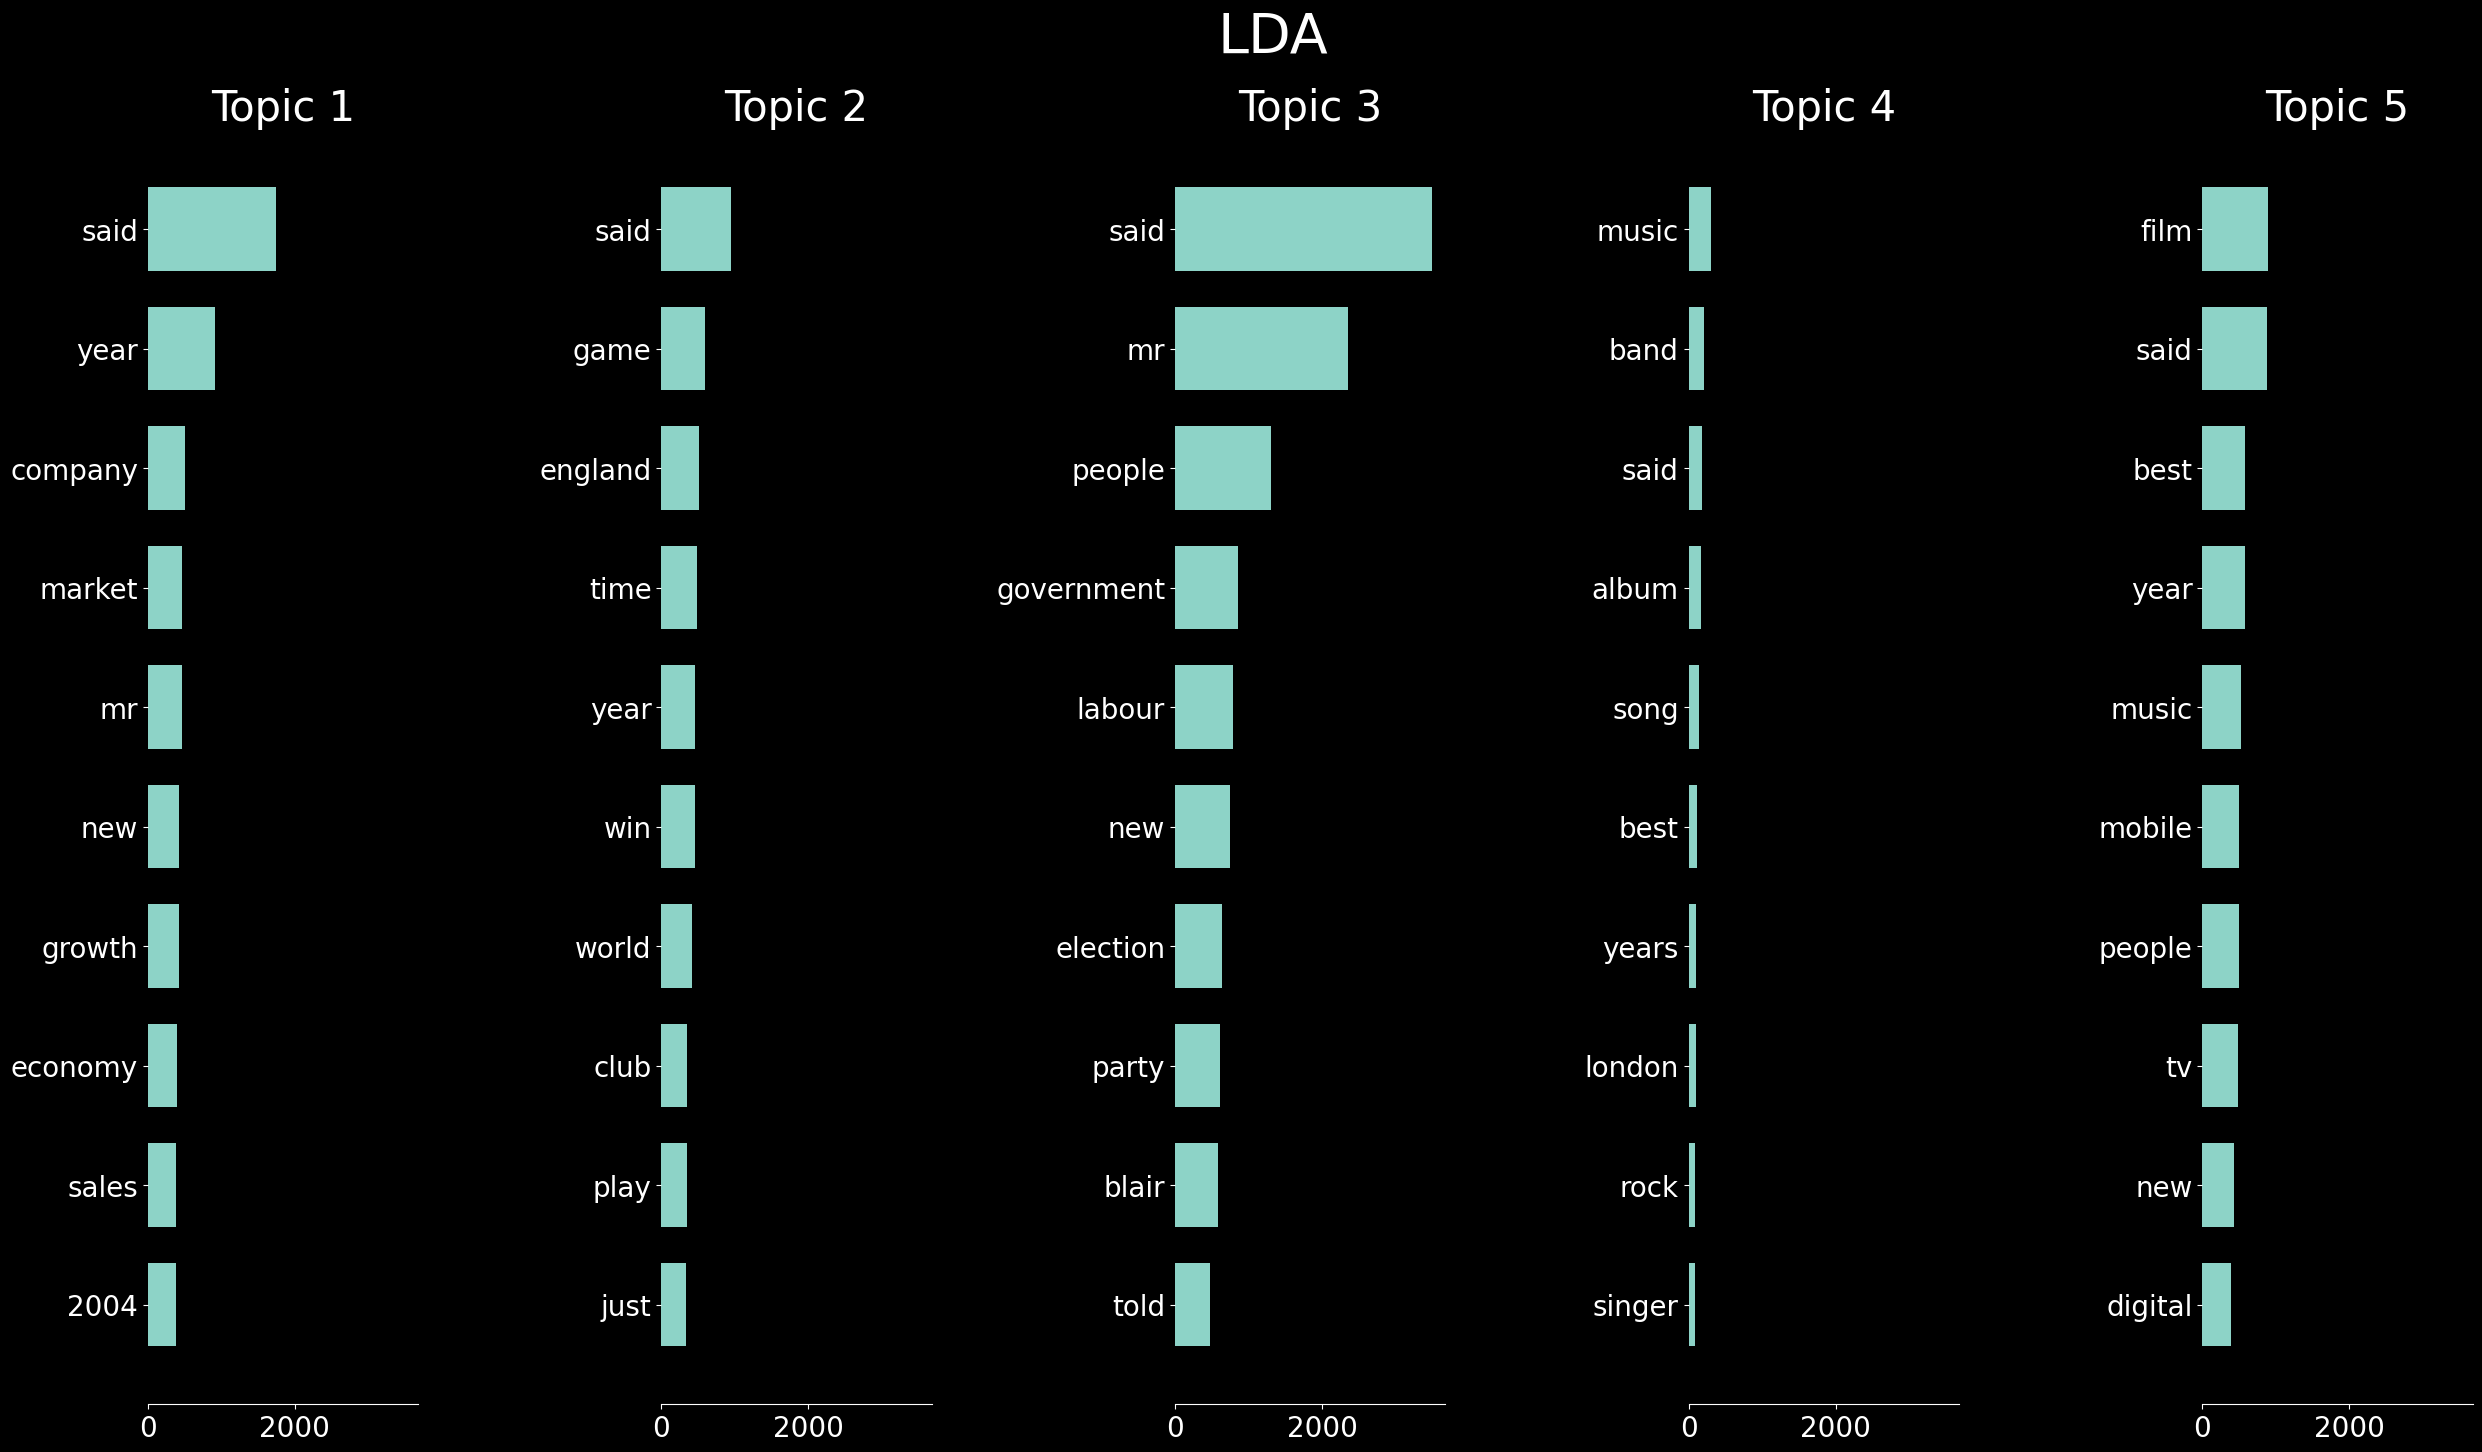

In [19]:
plot_top_words(lda_model, feature_names);

In [ ]:
# We have seen the topics which is the property of the model.
# Now we want to see our documents and want to know how they relate to our topic.
# We have seen topics by word matrix.

# Now we want to see documents by topics matrix.

In [20]:
Z = lda_model.transform(X) # Z is the hidden variable which shows distribution over topics.

In [21]:
Z.shape # document by topic matrix

(2225, 5)

# Select a random document and see if the topic are associated with it.

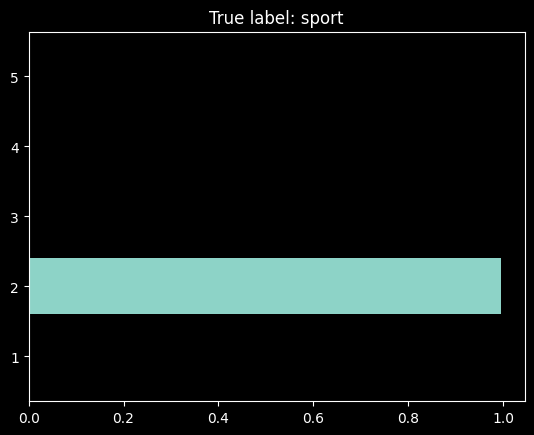

In [26]:
i = np.random.choice(len(df)) # select randon row from the data frame
z = Z[i]# To get the ith row from Z. we get 1D array which represents the distribution over topic
topics = np.arange(5) + 1 # Define the list of topics which are integers from 1 to 5.

# To draw a bar chart plotting the topic distribution along with the topics themselves as well as the true labels

fig, ax = plt.subplots()
ax.barh(topics, z)
ax.set_yticks(topics)
ax.set_title('True label: %s' % df.iloc[i]['category']);

In [27]:
def wrap(x):
  return textwrap.fill(x, replace_whitespace=False, fix_sentence_endings=True)

print(wrap(df.iloc[i]['text']))

owen determined to stay in madrid england forward michael owen has
told the bbc he is happy in spain and has no plans to quit real madrid
to return to the premiership in the near future.  but the 25-year-old
who has spent much of his time coming off the bench in la liga  did
not rule out a return to the premiership at some stage.  i m pleased
with the start i ve made here   he told bbc radio five live.  england
is my country.  it s definitely part of me but who knows whether  if
or when i ll be playing there again.  owen  who moved to the bernabeu
from liverpool last summer  has grabbed 11 goals for real but has been
unable to replace raul or ronaldo in the starting line-up.  however
he said he was delighted with the way his time in spain was going and
dismissed criticism of his decision to join real.  when i first came
there was a lot of scepticism back in england  any maybe some out here
he said.  people were saying  fourth-choice striker  what are you
going there for  you ll be sat 